In [2]:
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def plot_bias_variance_tradeoff(
    n_samples=60, degree=15, n_datasets=10, seed=12
):
  np.random.seed(seed)

  X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
  y_true_plot = (0.5 * X_plot**2 - 2 * X_plot + 3).ravel()

  linear_preds = []
  poly_preds = []

  fig, (ax_lin, ax_poly) = plt.subplots(1, 2, figsize=(15, 6))

  # Color palette so each dataset gets a distinct color
  colors = plt.cm.tab10(np.linspace(0, 1, n_datasets))
  scatter_handles = []

  for i in range(n_datasets):
    # 1. Generate data
    X = np.random.rand(n_samples) * 10
    y_true = 0.5 * X**2 - 2 * X + 3
    y = y_true + np.random.normal(0, 5, n_samples)
    X = X.reshape(-1, 1)

    # 2. Linear model
    linear_model = LinearRegression()
    linear_model.fit(X, y)
    y_linear_pred = linear_model.predict(X_plot)
    linear_preds.append(y_linear_pred)

    # 3. Polynomial model
    poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    poly_model.fit(X, y)
    y_poly_pred = poly_model.predict(X_plot)
    poly_preds.append(y_poly_pred)

    # Label only the first fitted line to avoid multiple line entries
    fit_label = 'Fitted models' if i == 0 else None

    # 4. Scatter & lines (each dataset gets a distinct color)
    data_alpha = np.min([1, np.sqrt(50 / (n_datasets * n_samples))])
    sc_lin = ax_lin.scatter(
        X, y, color=colors[i], alpha=data_alpha, s=20, edgecolors='none'
    )
    ax_lin.plot(
        X_plot,
        y_linear_pred,
        color='steelblue',
        linestyle='--',
        linewidth=1.3,
        alpha=0.7,
        label=fit_label,
    )

    ax_poly.scatter(
        X, y, color=colors[i], alpha=data_alpha, s=20, edgecolors='none'
    )
    ax_poly.plot(
        X_plot,
        y_poly_pred,
        color='steelblue',
        linestyle='--',
        linewidth=1.3,
        alpha=0.7,
        label=fit_label,
    )

    scatter_handles.append(sc_lin)

  linear_preds = np.array(linear_preds)
  poly_preds = np.array(poly_preds)

  # Expected predictions E[\hat{f}(x)]
  avg_linear_pred = np.mean(linear_preds, axis=0)
  avg_poly_pred = np.mean(poly_preds, axis=0)

  # Bias^2 and Variance
  lin_bias2 = np.mean((avg_linear_pred - y_true_plot) ** 2)
  poly_bias2 = np.mean((avg_poly_pred - y_true_plot) ** 2)

  lin_variance = np.mean(np.var(linear_preds, axis=0))
  poly_variance = np.mean(np.var(poly_preds, axis=0))

  # True Function f(x) and Average Prediction Line E[\hat{f}(x)]
  (line_true,) = ax_lin.plot(
      X_plot, y_true_plot, 'k--', linewidth=2.5, label=r'True function $f$'
  )
  (line_avg,) = ax_lin.plot(
      X_plot,
      avg_linear_pred,
      'r-',
      linewidth=2.5,
      label=r'Avg prediction $\text{E}[\hat{f}]$',
  )

  ax_poly.plot(
      X_plot, y_true_plot, 'k--', linewidth=2.5, label=r'True function $f$'
  )
  ax_poly.plot(
      X_plot,
      avg_poly_pred,
      'r-',
      linewidth=2.5,
      label=r'Avg prediction $\text{E}[\hat{f}]$',
  )

  # Setup Legend using HandlerTuple for multi-colored scatter representation
  line_fitted = ax_lin.get_lines()[0]  # Grab fitted models line entry

  for ax in (ax_lin, ax_poly):
    ax.set_ylim(-15, 45)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(
        handles=[
            tuple(scatter_handles[:4]),
            line_fitted,
            line_true,
            line_avg,
        ],
        labels=[
            'Datasets (1–10)',
            'Fitted models',
            r'True function $f$',
            r'Avg prediction $\text{E}[\hat{f}]$',
        ],
        handler_map={tuple: HandlerTuple(ndivide=None)},
        loc='upper left',
        fontsize=11,
        frameon=True,
        facecolor='white',
        framealpha=0.9,
    )

  ax_lin.set_title(
      'Linear Regression (High Bias, Low Variance)\n'
      f'Bias²: {lin_bias2:.2f} | Variance: {lin_variance:.2f}',
      fontsize=13,
  )
  ax_poly.set_title(
      f'Polynomial deg={degree} (Low Bias, High Variance)\n'
      f'Bias²: {poly_bias2:.2f} | Variance: {poly_variance:.2f}',
      fontsize=13,
  )

  fig.suptitle(
      f'{n_datasets} datasets with N={n_samples} samples', fontsize=18
  )
  plt.tight_layout()

  return fig

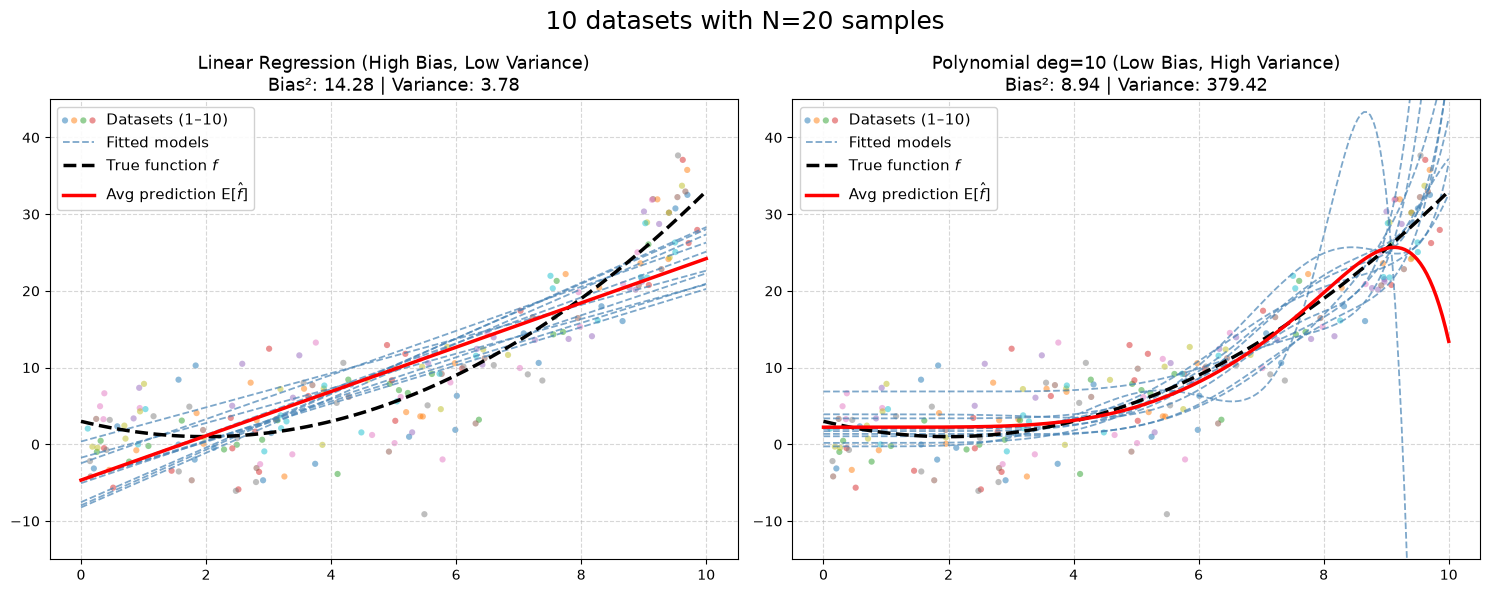

In [3]:
fig = plot_bias_variance_tradeoff(n_samples=20, degree=10, n_datasets=10, seed=42)
fig.savefig("beamer/images/bias_variance_tradeoff_n_20.png")

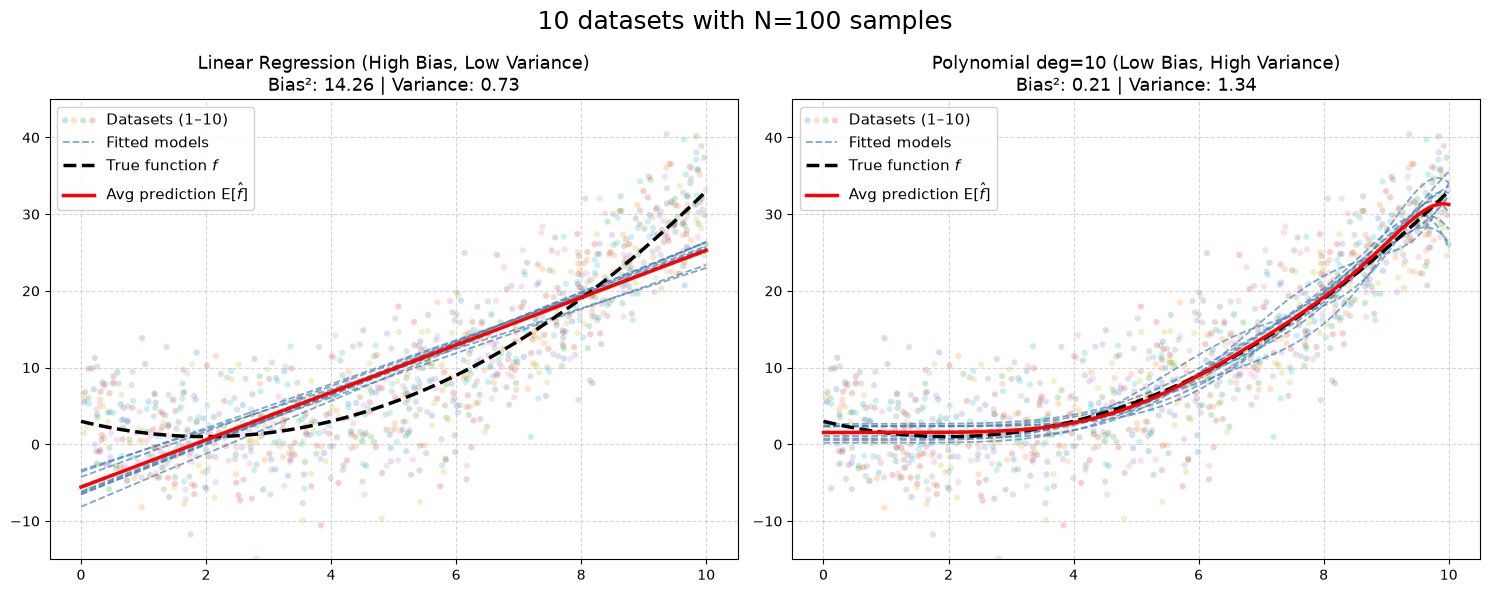

In [4]:
fig = plot_bias_variance_tradeoff(n_samples=100, degree=10, n_datasets=10, seed=42)
fig.savefig("beamer/images/bias_variance_tradeoff_n_100.png")

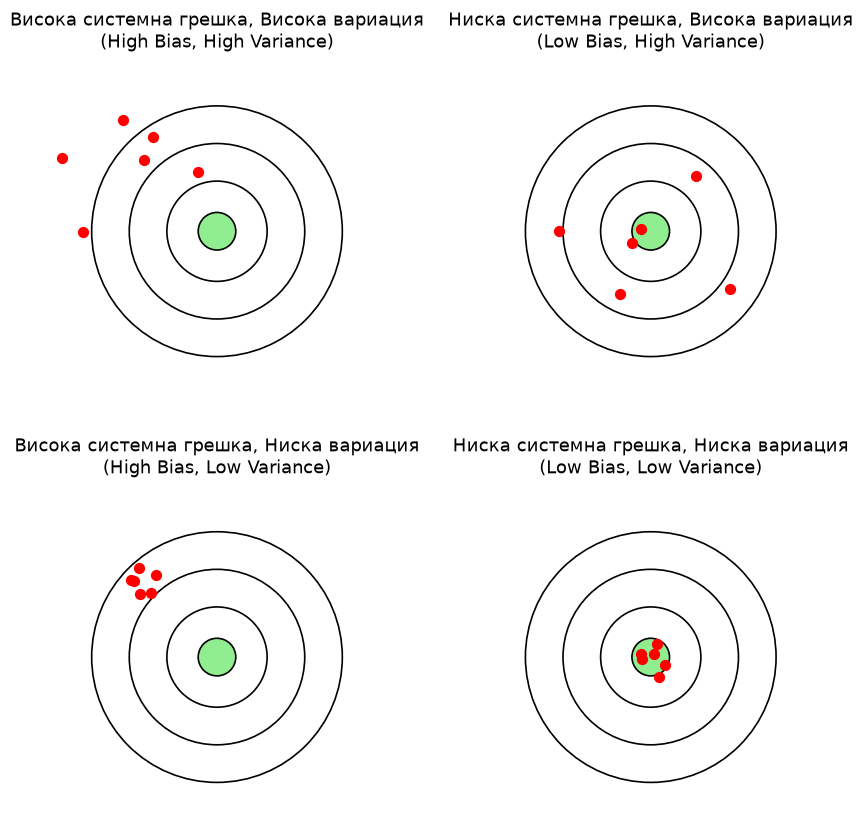

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np


def plot_bias_variance_targets(with_conclusion=False):
  # Настройки на четирите случая: (Заглавие, Отместване, Вариация)
  cases = [
      (
          "Висока системна грешка, Висока вариация\n(High Bias, High"
          " Variance)",
          [-0.3, 0.3],
          0.6,
      ),
      (
          "Ниска системна грешка, Висока вариация\n(Low Bias, High Variance)",
          [0, 0],
          0.35,
      ),
      (
          "Висока системна грешка, Ниска вариация\n(High Bias, Low Variance)",
          [-0.6, 0.6],
          0.08,
      ),
      (
          "Ниска системна грешка, Ниска вариация\n(Low Bias, Low Variance)",
          [0, 0],
          0.125,
      ),
  ]

  fig, axes = plt.subplots(2, 2, figsize=(13, 10))
  axes = axes.flatten()
  np.random.seed(34)

  for ax, (title, offset, var) in zip(axes, cases):
    radii = [1.0, 0.7, 0.4, 0.15]
    for i, r in enumerate(radii):
      fill = True if i == len(radii) - 1 else False
      color = 'lightgreen' if i == len(radii) - 1 else 'black'

      circle = plt.Circle(
          (0, 0),
          r,
          fill=fill,
          linewidth=1.2,
          facecolor=color,
          edgecolor='black',
      )
      ax.add_patch(circle)

    x = np.random.normal(loc=offset[0], scale=var, size=6)
    y = np.random.normal(loc=offset[1], scale=var, size=6)

    ax.scatter(x, y, color='red', s=50, zorder=5)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')

    if not with_conclusion:
      ax.set_title(title, fontsize=13, pad=15)

  # w_pad контролира хоризонталното разстояние между двете колони
  plt.tight_layout(rect=[0.14, 0.08, 0.86, 0.92], w_pad=5.0, h_pad=3.0)

  if not with_conclusion:
    return fig

  # --- ДОБАВЯНЕ НА СТРЕЛКИТЕ ---

  # 1. Горе: Стрелка надясно ("По-добър модел")
  arrow_top = FancyArrowPatch(
      (0.25, 0.94),
      (0.75, 0.94),
      transform=fig.transFigure,
      arrowstyle='->',
      mutation_scale=20,
      linewidth=2,
      color='black',
  )
  fig.add_artist(arrow_top)
  fig.text(
      0.5,
      0.955,
      'По-гъвкав модел',
      ha='center',
      va='bottom',
      fontsize=13,
      weight='bold',
  )

  # 2. Долу: Стрелка надясно ("По-добър модел")
  arrow_bottom = FancyArrowPatch(
      (0.25, 0.06),
      (0.75, 0.06),
      transform=fig.transFigure,
      arrowstyle='->',
      mutation_scale=20,
      linewidth=2,
      color='black',
  )
  fig.add_artist(arrow_bottom)
  fig.text(
      0.5,
      0.04,
      'По-гъвкав модел',
      ha='center',
      va='top',
      fontsize=13,
      weight='bold',
  )

  # 3. Ляво: Стрелка надолу
  arrow_left = FancyArrowPatch(
      (0.09, 0.8),
      (0.09, 0.2),
      transform=fig.transFigure,
      arrowstyle='->',
      mutation_scale=20,
      linewidth=2,
      color='black',
  )
  fig.add_artist(arrow_left)
  fig.text(
      0.04,
      0.5,
      'Повече данни\nПо-прост модел',
      ha='center',
      va='center',
      rotation=90,
      fontsize=13,
      weight='bold',
  )

  # 4. Дясно: Стрелка надолу
  arrow_right = FancyArrowPatch(
      (0.91, 0.8),
      (0.91, 0.2),
      transform=fig.transFigure,
      arrowstyle='->',
      mutation_scale=20,
      linewidth=2,
      color='black',
  )
  fig.add_artist(arrow_right)
  fig.text(
      0.96,
      0.5,
      'Повече данни\nПо-прост модел',
      ha='center',
      va='center',
      rotation=-90,
      fontsize=13,
      weight='bold',
  )

  # 5. Диагонална стрелка: Координати, съобразени със съотношението (13:10)
  arrow_diag = FancyArrowPatch(
      (0.59, 0.565),
      (0.43, 0.39),
      transform=fig.transFigure,
      arrowstyle='->',
      mutation_scale=20,
      linewidth=2,
      color='darkred',
  )
  fig.add_artist(arrow_diag)

  # Текст с rotation=35, за да съвпада точно с наклона на стрелката
  fig.text(
      0.5,
      0.5,
      'По-простите модели могат да \nдобавят систематична грешка!!!',
      ha='center',
      va='center',
      rotation=40,
      fontsize=12,
      weight='bold',
      color='darkred',
  )

  return fig


fig = plot_bias_variance_targets()
fig.savefig(
    './beamer/images/bullseye_bias_variance.png',
    bbox_inches='tight',
    pad_inches=0.2,
)

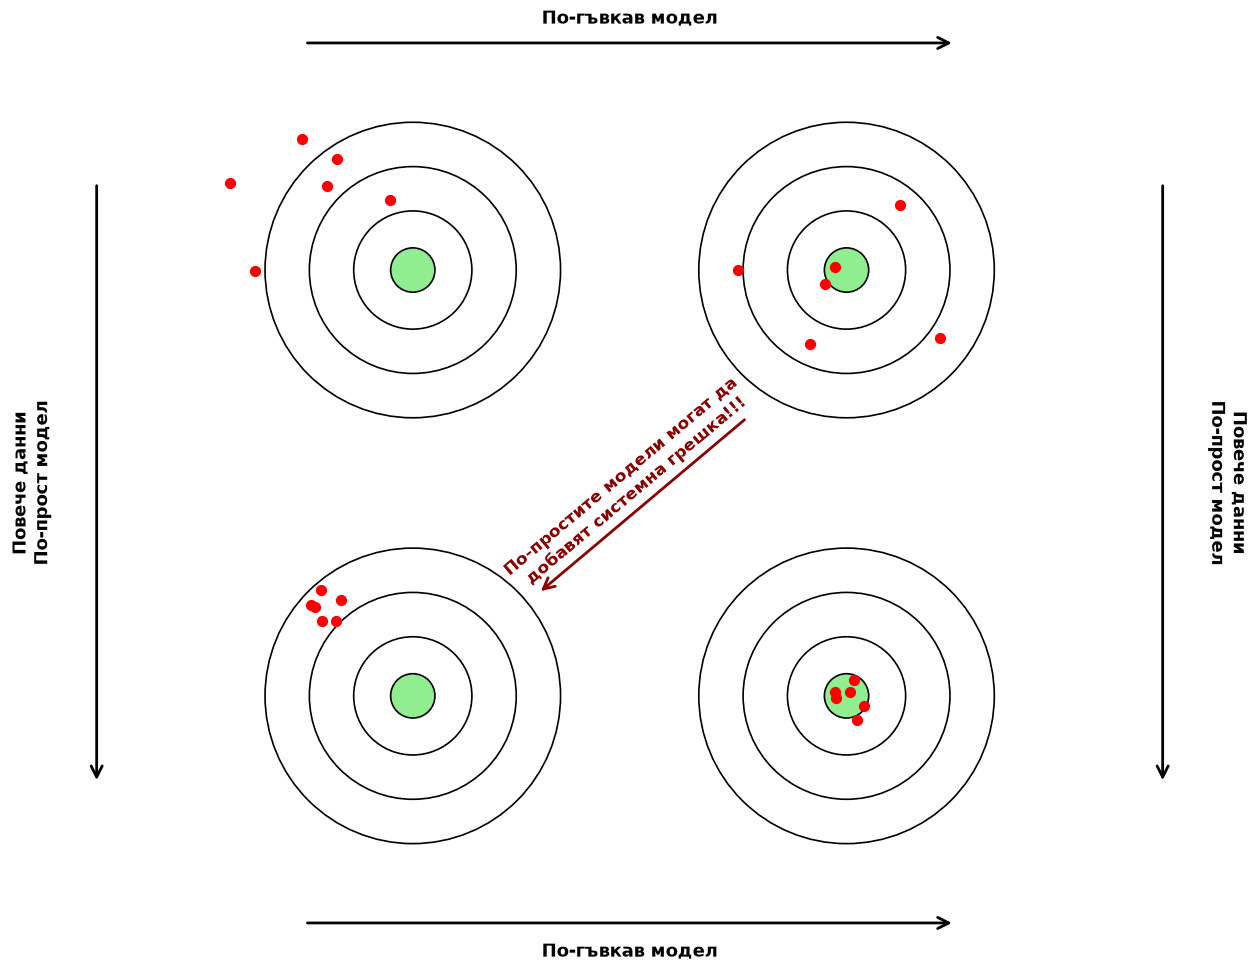

In [4]:
fig = plot_bias_variance_targets(with_conclusion=True)
fig.savefig('./beamer/images/bullseye_bias_variance_with_conclusion.png', bbox_inches='tight', pad_inches=0.2)